In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import data_analytics_lib as dal
import random


# Exercise 1

## Python function to read in the data from the file Baseball_Team_Salaries.csv and put the data into the data structures

In [2]:
def read_baseball_data(file_path):

    year = []
    team = []
    wins = []
    losses = []
    win_percentage = []
    salary = []
    
    with open(file_path, 'r') as file:
        data = file.readlines()
    
        for line in data[1:]:  # Skip header line
            lines = line.split(',')
            year.append(int(lines[0]))
            team.append(lines[1])
            wins.append(int(lines[2]))
            losses.append(int(lines[3]))
            win_percentage.append(float(lines[4]))
            salary.append(float(lines[5]))
        
    return year, team, wins, losses, win_percentage, salary



years_list, teams_list, wins_list, losses_list, wp_list, salary_list = read_baseball_data('Baseball_Team_Salaries.csv')



def organize_data_by_year_and_team(years_list, teams_list, wins_list, losses_list, wp_list, salary_list):
    
    yearly_data = {}
    team_data = {}
    
    unique_years = np.unique(years_list)
    
    for year in unique_years:
        
        temp_teams_list = []
        temp_wins_list = []
        temp_losses_list = []
        temp_wp_list = []
        temp_salary_list = []
        
        for i in range(len(years_list)):
            if years_list[i] == year:
                temp_teams_list.append(teams_list[i])
                temp_wins_list.append(wins_list[i])
                temp_losses_list.append(losses_list[i])
                temp_wp_list.append(wp_list[i])
                temp_salary_list.append(salary_list[i])
                
        yearly_data[year] = {
            'teams': temp_teams_list,
            'wins': temp_wins_list,
            'losses': temp_losses_list,
            'win_percentage': temp_wp_list,
            'salary': temp_salary_list
        }
        
    unique_teams = np.unique(teams_list)

    for team in unique_teams:
        
        temp_years_list = []
        temp_wins_list = []
        temp_losses_list = []
        temp_wp_list = []
        temp_salary_list = []
        
        for i in range(len(teams_list)):
            if teams_list[i] == team:
                temp_years_list.append(years_list[i])
                temp_wins_list.append(wins_list[i])
                temp_losses_list.append(losses_list[i])
                temp_wp_list.append(wp_list[i])
                temp_salary_list.append(salary_list[i])
                
        team_data[team] = {
            'years': temp_years_list,
            'wins': temp_wins_list,
            'losses': temp_losses_list,
            'win_percentage': temp_wp_list,
            'salary': temp_salary_list
        }
        
    return yearly_data, team_data
    
yearly_data_structure, team_data_structure = organize_data_by_year_and_team(years_list, teams_list, wins_list, losses_list, wp_list, salary_list)

print(yearly_data_structure)
print(team_data_structure)
        

{np.int64(1986): {'teams': ['New York Mets', 'Philadelphia Phillies', 'St. Louis Cardinals', 'Montreal Expos', 'Chicago Cubs', 'Pittsburgh Pirates', 'Houston Astros', 'Cincinnati Reds', 'San Francisco Giants', 'San Diego Padres', 'Los Angeles Dodgers', 'Atlanta Braves'], 'wins': [108, 86, 79, 78, 70, 64, 96, 86, 83, 74, 73, 72], 'losses': [54, 75, 82, 83, 90, 98, 66, 76, 79, 88, 89, 89], 'win_percentage': [0.667, 0.534, 0.491, 0.484, 0.438, 0.395, 0.593, 0.531, 0.512, 0.457, 0.451, 0.447], 'salary': [13597780.0, 11715166.0, 9481677.0, 11937394.0, 16904832.0, 10231500.0, 10368276.0, 11785036.0, 8682000.0, 11897522.0, 15471276.0, 17940286.0]}, np.int64(1987): {'teams': ['St. Louis Cardinals', 'New York Mets', 'Montreal Expos', 'Pittsburgh Pirates', 'Philadelphia Phillies', 'Chicago Cubs', 'San Francisco Giants', 'Cincinnati Reds', 'Houston Astros', 'Los Angeles Dodgers', 'Atlanta Braves', 'San Diego Padres'], 'wins': [95, 92, 91, 80, 80, 76, 90, 84, 76, 73, 69, 65], 'losses': [67, 70, 71

# Exercise 2

## 1. Use your existing statistics function to compute mean , median ,standard deviation, min and max for the all the team salaries for year each.

In [3]:
# Salary Statistics Over Years
salary_means = []
salary_medians = []
salary_stds = []
salary_mins = []
salary_maxs = []

for i in range(len(yearly_data_structure)):
    
    year = list(yearly_data_structure.keys())[i]
    salaries = yearly_data_structure[year]['salary']
    
    mean_salary = dal.main_stats(salaries)['mean']
    median_salary = dal.main_stats(salaries)['median']
    std_salary = dal.main_stats(salaries)['std_dev']
    min_salary = dal.main_stats(salaries)['min']
    max_salary = dal.main_stats(salaries)['max']
    
    salary_means.append(mean_salary)
    salary_medians.append(median_salary)
    salary_stds.append(std_salary)
    salary_mins.append(min_salary)
    salary_maxs.append(max_salary)


## 2. Write a function to produce a plots of each of these statistics, all on one plot, as a function of year.

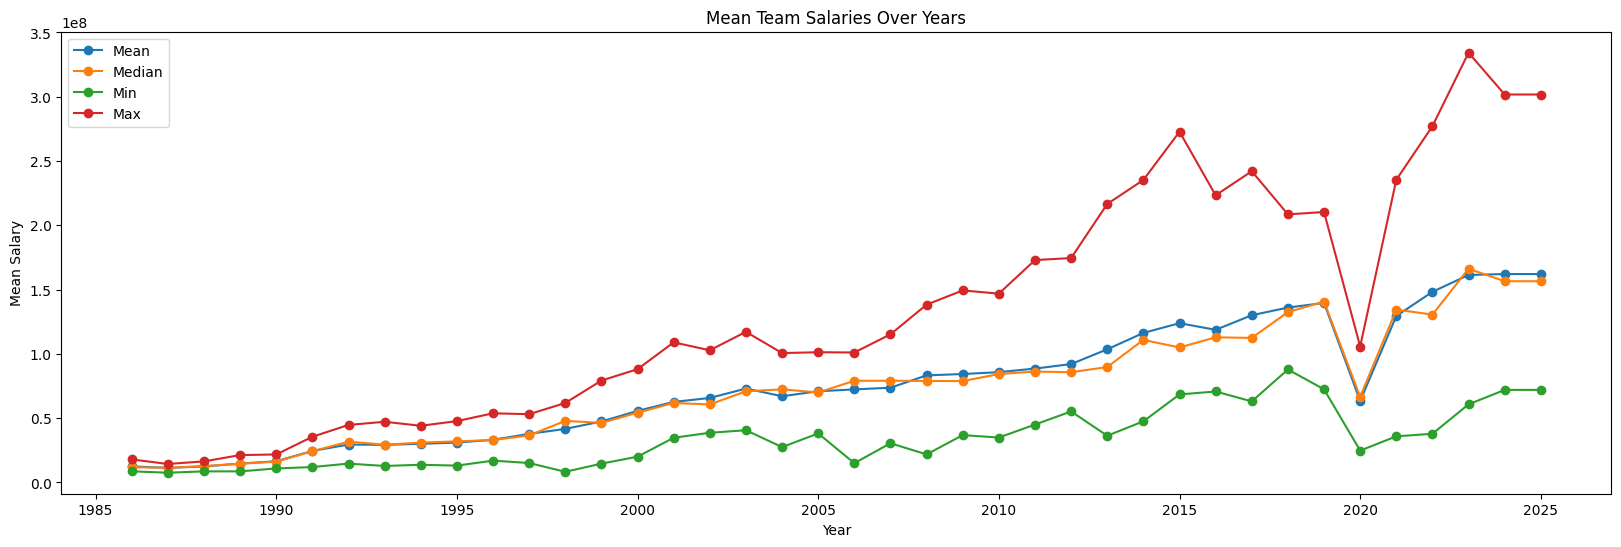

In [4]:
plt.figure(figsize=(20, 6))

plt.plot(list(yearly_data_structure.keys()), salary_means, marker='o', label='Mean')
plt.plot(list(yearly_data_structure.keys()), salary_medians, marker='o', label='Median')
plt.plot(list(yearly_data_structure.keys()), salary_mins, marker='o', label='Min')
plt.plot(list(yearly_data_structure.keys()), salary_maxs, marker='o', label='Max')

plt.legend()
plt.title('Mean Team Salaries Over Years')
plt.xlabel('Year')
plt.ylabel('Mean Salary')
plt.show()

## 3. Use your generic XY plot function, to plot the standard deviation of the team salaries for each year.

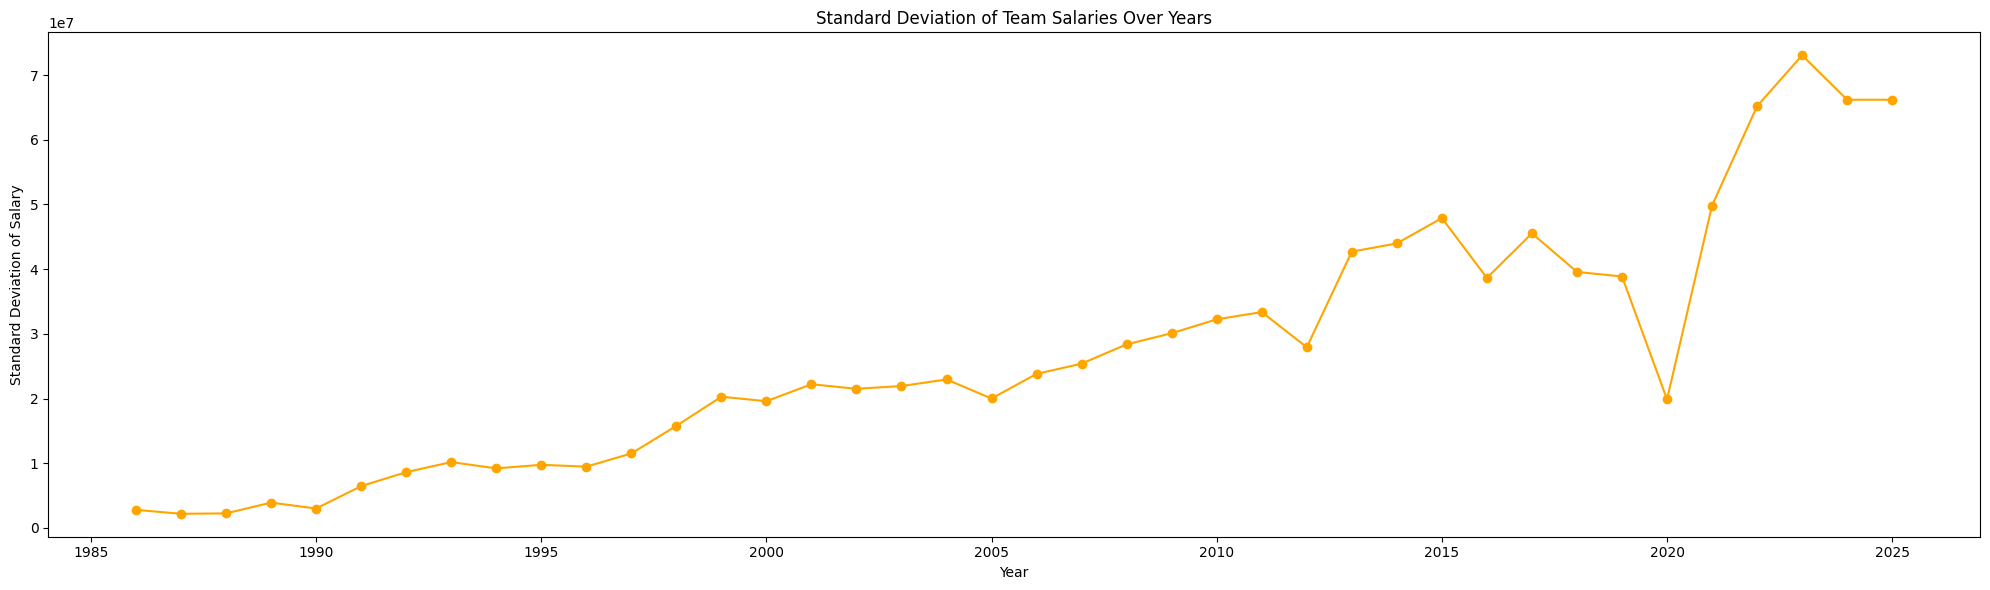

In [5]:
plt.figure(figsize=(20, 6))

dal.xy_plot(list(yearly_data_structure.keys()), salary_stds, 'Year', 'Standard Deviation of Salary', 'Standard Deviation of Team Salaries Over Years', marker='o', color='orange')

## 4. For each year, compute the ratio of the salary standard deviation to the salary mean. Plot this ratio as a function of years.

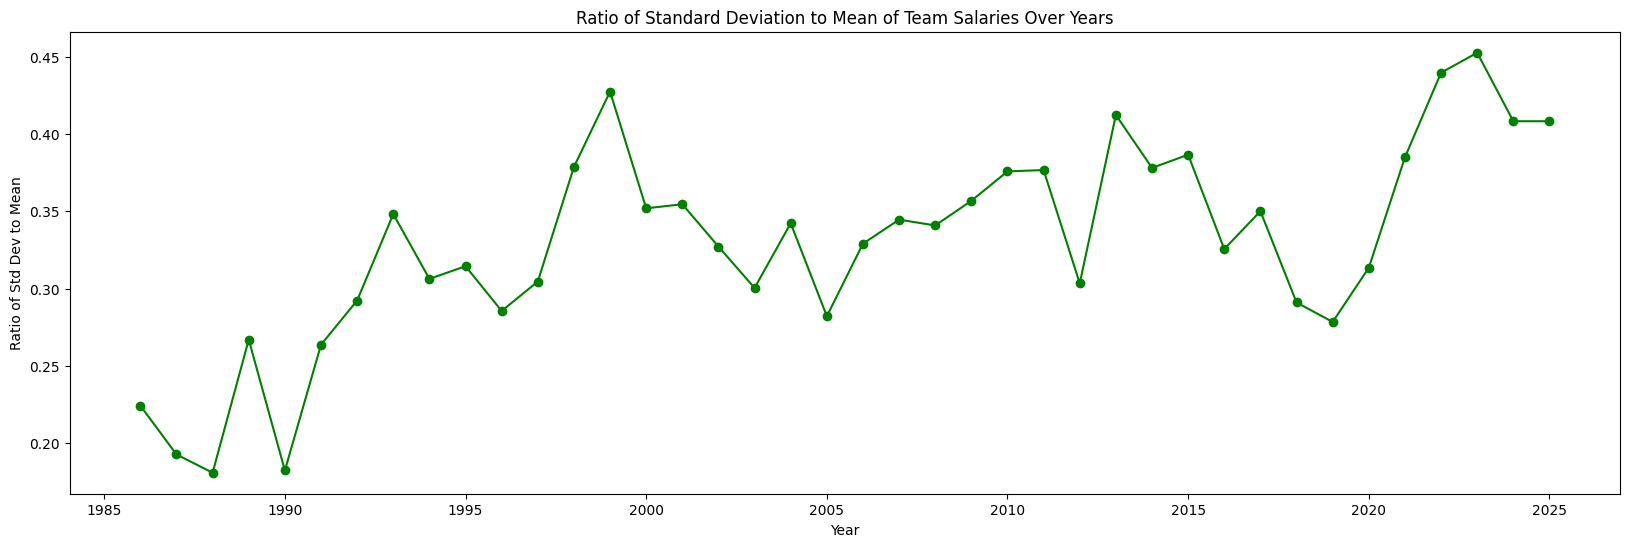

In [6]:
ratio_std_mean = np.array(salary_stds)/np.array(salary_means)

plt.figure(figsize=(20, 6))
plt.plot(list(yearly_data_structure.keys()), ratio_std_mean, marker='o', color='green')
plt.title('Ratio of Standard Deviation to Mean of Team Salaries Over Years')
plt.xlabel('Year')
plt.ylabel('Ratio of Std Dev to Mean')
plt.show()

# Exercise 3

## Write a python function to compute the correlation coefficient, of winning percentage and salary, for all teams for each year, 1986 – 2025. From these results produce a plot of the data showing the correlation coefficient versus time.

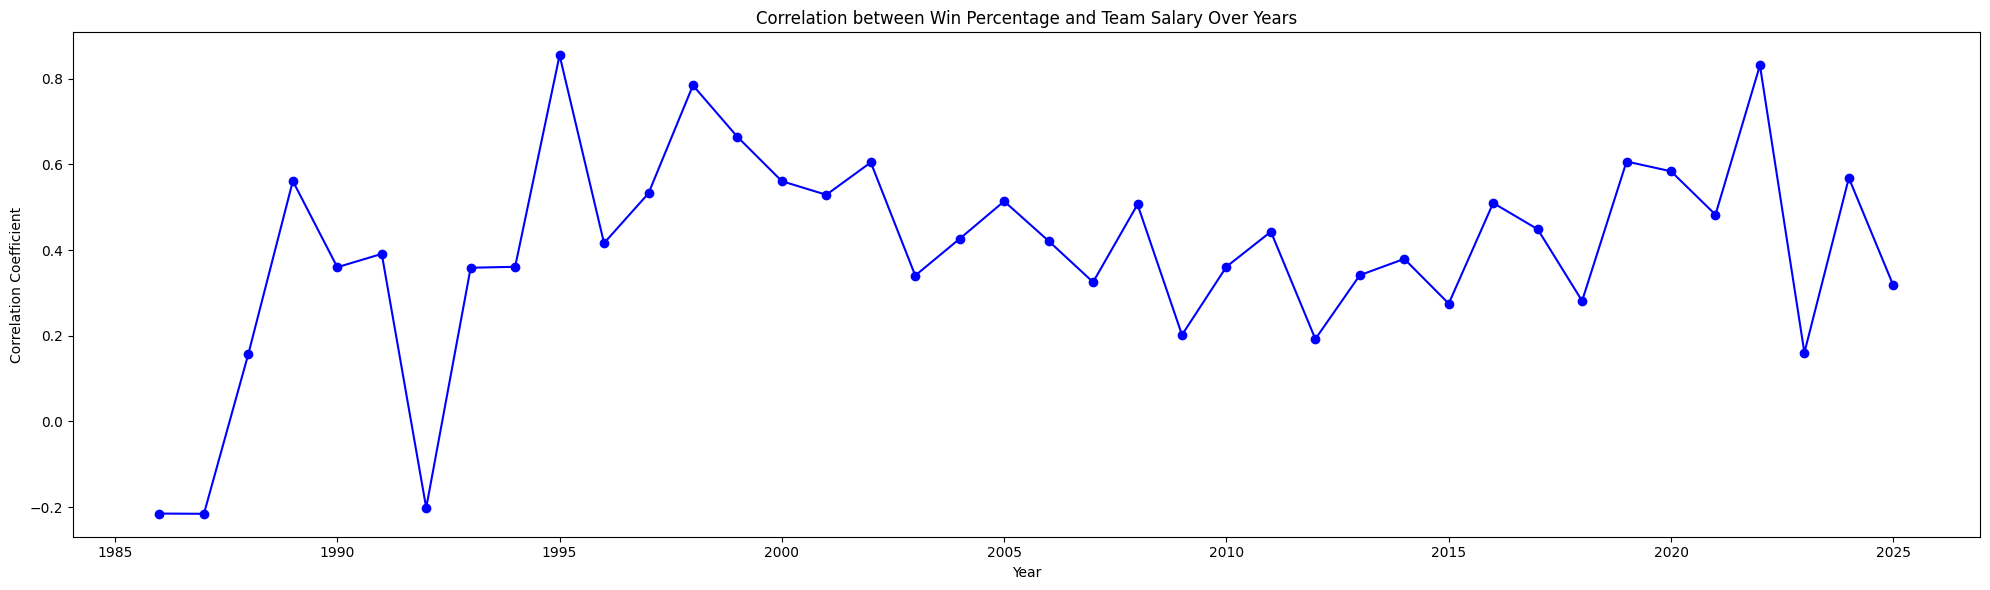

In [7]:
def corelation_wp_salary(yearly_data_structure):
    correlation_results = {}
    
    for year in yearly_data_structure:
        win_percentages = yearly_data_structure[year]['win_percentage']
        salaries = yearly_data_structure[year]['salary']
        
        correlation = dal.find_data_correlation(win_percentages, salaries)
        correlation_results[year] = correlation
        
    return correlation_results

corelation_coef_wp_salary = corelation_wp_salary(yearly_data_structure)

plt.figure(figsize=(20, 6))
dal.xy_plot(list(corelation_coef_wp_salary.keys()), list(corelation_coef_wp_salary.values()), 'Year', 'Correlation Coefficient', 'Correlation between Win Percentage and Team Salary Over Years', marker = 'o', color = 'blue')

    

# Exercise 4

## Python function to compute the correlation coefficient, between winning percentage and salary, for the top 5 teams by winning percentage, 1986 – 2025.

In [8]:
def top_5_teams_correlation_coef(yearly_data_structure):
    
    top_5_correlation = {}
    top_5_team_stats = {}
    
    bot_5_teams_correlation = {}
    bot_5_team_stats = {}
    
    team_wp_tuples = []
    
    for year in yearly_data_structure:
        
        teams = yearly_data_structure[year]['teams']
        win_percentages = yearly_data_structure[year]['win_percentage']
        salaries = yearly_data_structure[year]['salary']
        
        for i in range(len(teams)):
            team_wp_tuples.append((teams[i], win_percentages[i], salaries[i]))
        
        # Sort by win percentage and get top 5 teams
        sorted_by_wp = sorted(team_wp_tuples, key=lambda x: x[1], reverse=True)
    
        top_5_teams = sorted_by_wp[:5]
        bot_5_teams = sorted_by_wp[-5:]
        
        # Account for when winning percentages are the same, include all teams with the same winning percentage as the 5th team in the top 5 and the 5th team in the bottom 5
        
        count = 5
         
        while count < len(sorted_by_wp) and sorted_by_wp[count][1] == top_5_teams[-1][1]:
            top_5_teams.append(sorted_by_wp[count])
            count += 1 
            
        count = len(sorted_by_wp) - 6
        
        while count >= 0 and sorted_by_wp[count][1] == bot_5_teams[0][1]:
            bot_5_teams.insert(0, sorted_by_wp[count])
            count -= 1 
                 
        win_percentages_top5 = [team[1] for team in top_5_teams]
        salaries_top5 = [team[2] for team in top_5_teams]
        
        correlation_top5 = dal.find_data_correlation(win_percentages_top5, salaries_top5)
        top_5_correlation[year] = correlation_top5
        top_5_team_stats[year] = top_5_teams
        
        win_percentages_bot5 = [team[1] for team in bot_5_teams]
        salaries_bot5 = [team[2] for team in bot_5_teams]
        
        correlation_bot5 = dal.find_data_correlation(win_percentages_bot5, salaries_bot5)
        bot_5_teams_correlation[year] = correlation_bot5
        bot_5_team_stats[year] = bot_5_teams
        
        
        # Reset for the next loop/year
        team_wp_tuples.clear()  
    
    return top_5_correlation, top_5_team_stats, bot_5_teams_correlation, bot_5_team_stats



corelation_of_top5_teams, top_stats, corelation_of_bot5_teams, bot_stats = top_5_teams_correlation_coef(yearly_data_structure)

# plt.figure(figsize=(20, 6))
# dal.xy_plot(list(corelation_of_top5_teams.keys()), list(corelation_of_top5_teams.values()), 'Year', 'Correlation Coefficient', 'Correlation between Win Percentage and Team Salary for Top 5 Teams Over Years', marker = 'o', color = 'red')


## 1. Produce a plot for the correlation coefficient for all teams for years 1986 – 2025, that colors all points with a negative cc red and those with a positive cc green. Connect all the points with a line. Draw a horizontal lines on the plot showing the mean of the percentages, and the mean +/- one standard deviation.

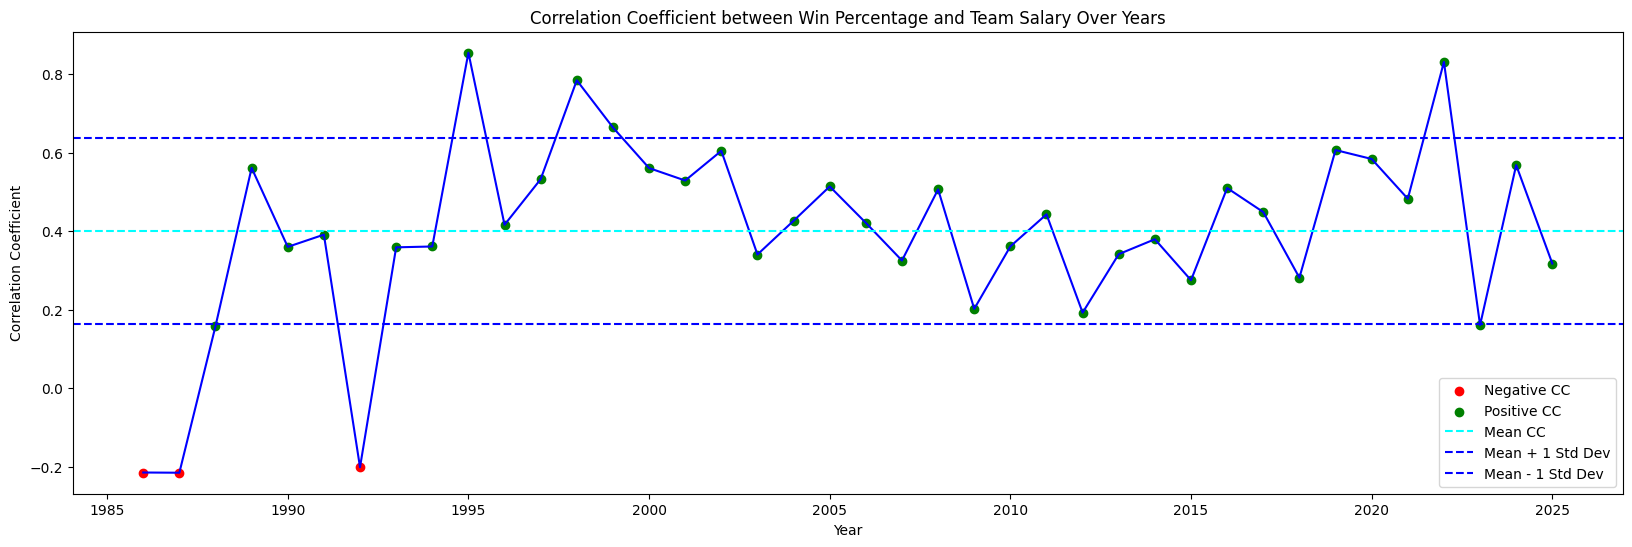

In [9]:
def neg_cc_vs_pos_cc(corelation_data):
    neg_cc = []
    pos_cc = []
    neg_cc_years = []
    pos_cc_years = []
    
    for i in corelation_data:
        if corelation_data[i] < 0:
            neg_cc.append(corelation_data[i])
            neg_cc_years.append(i)
        else:
            pos_cc.append(corelation_data[i])
            pos_cc_years.append(i)
            
    return neg_cc_years, neg_cc, pos_cc_years, pos_cc

neg_cc_years, neg_cc_pts, pos_cc_years, pos_cc_pts = neg_cc_vs_pos_cc(corelation_coef_wp_salary)

plt.figure(figsize=(20, 6))

plt.scatter(neg_cc_years, neg_cc_pts, color='red', label='Negative CC')
plt.scatter(pos_cc_years, pos_cc_pts, color='green', label='Positive CC')
plt.plot(list(corelation_coef_wp_salary.keys()), list(corelation_coef_wp_salary.values()), color = 'blue')

plt.axhline(y = np.mean(list(corelation_coef_wp_salary.values())), color='cyan', linestyle='--', label='Mean CC')
plt.axhline(y = np.mean(list(corelation_coef_wp_salary.values())) + np.std(list(corelation_coef_wp_salary.values())), color='blue', linestyle='--', label='Mean + 1 Std Dev')
plt.axhline(y = np.mean(list(corelation_coef_wp_salary.values())) - np.std(list(corelation_coef_wp_salary.values())), color='blue', linestyle='--', label='Mean - 1 Std Dev')

plt.title('Correlation Coefficient between Win Percentage and Team Salary Over Years')
plt.xlabel('Year')
plt.ylabel('Correlation Coefficient')
plt.legend()

## 2. Do the same for the correlation coefficient for the “best 5” teams.

[np.float64(0.6864705931354188), np.float64(0.6344375289085419), np.float64(0.8370193303696626), np.float64(0.2959498530406322), np.float64(0.6016087215858206), np.float64(0.7982164854551748), np.float64(0.9253111222925221), np.float64(0.7910667402827347), np.float64(0.641783293062483), np.float64(0.6499668045357937), np.float64(0.7562947592475608), np.float64(0.12695175335560735), np.float64(0.6232428898813767), np.float64(0.25823770775101484), np.float64(0.43592431105907964), np.float64(0.27829653411574784), np.float64(0.5617415723477575), np.float64(0.9233130434392289), np.float64(0.648134896916247), np.float64(0.4910982392020667), np.float64(0.7738329872924301), np.float64(0.5761722720797423), np.float64(0.8145577708275498), np.float64(0.4832485937720223), np.float64(0.6621712133555379), np.float64(0.6737164192780067)]


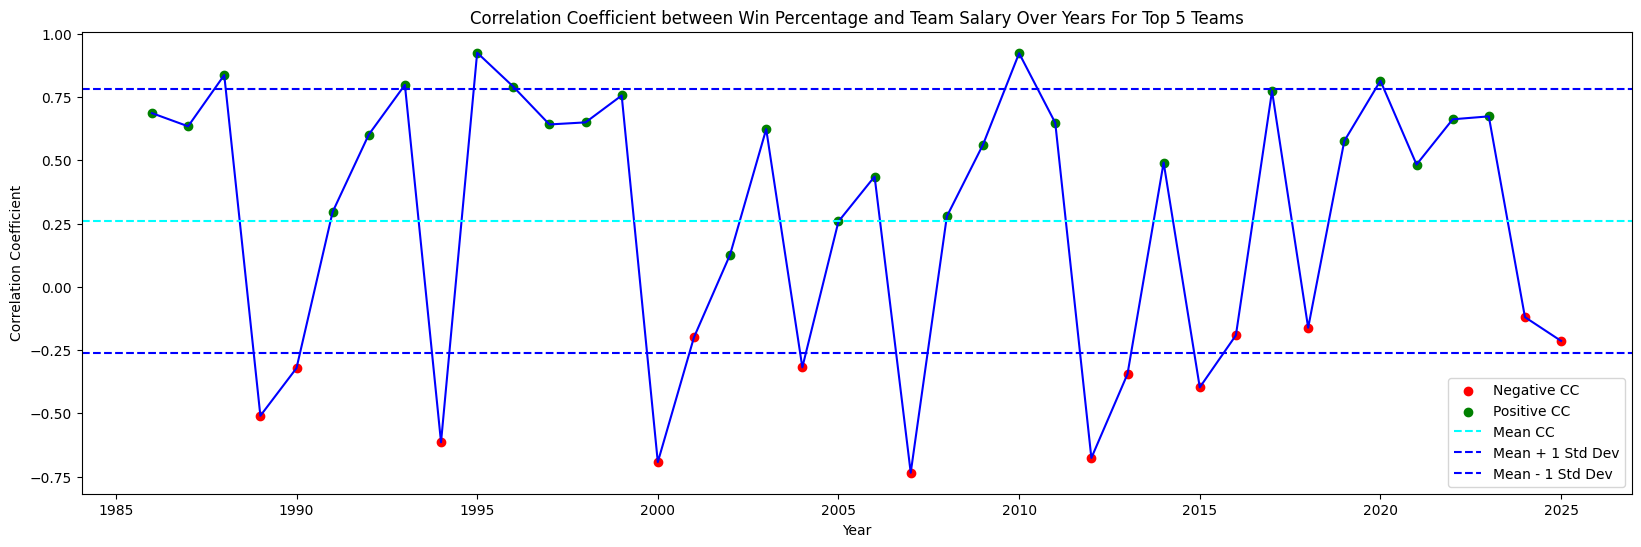

In [10]:
top_5_neg_cc_years, top_5_neg_cc_pts, top_5_pos_cc_years, top_5_pos_cc_pts = neg_cc_vs_pos_cc(corelation_of_top5_teams)

print(top_5_pos_cc_pts)

plt.figure(figsize=(20, 6))

plt.scatter(top_5_neg_cc_years, top_5_neg_cc_pts, color='red', label='Negative CC')
plt.scatter(top_5_pos_cc_years, top_5_pos_cc_pts, color='green', label='Positive CC')
plt.plot(list(corelation_of_top5_teams.keys()), list(corelation_of_top5_teams.values()), color = 'blue')

plt.axhline(y = np.mean(list(corelation_of_top5_teams.values())), color='cyan', linestyle='--', label='Mean CC')
plt.axhline(y = np.mean(list(corelation_of_top5_teams.values())) + np.std(list(corelation_of_top5_teams.values())), color='blue', linestyle='--', label='Mean + 1 Std Dev')
plt.axhline(y = np.mean(list(corelation_of_top5_teams.values())) - np.std(list(corelation_of_top5_teams.values())), color='blue', linestyle='--', label='Mean - 1 Std Dev')

plt.title('Correlation Coefficient between Win Percentage and Team Salary Over Years For Top 5 Teams')
plt.xlabel('Year')
plt.ylabel('Correlation Coefficient')
plt.legend()

## 3. Compute the salary statistics of the 5 best teams and 5 worst teams for all years.

In [11]:
top_5_salary = []
bot_5_salary = []
count= 0 

for year in top_stats:
    for i in range(len(top_stats[year])):
        for team in top_stats[year]:
            top_5_salary.append(team[2])           

for year in bot_stats:
    for team in bot_stats[year]:
        for i in range(len(bot_stats[year])):
            bot_5_salary.append(team[2])
        
        
salary_stats_top5 = dal.main_stats(top_5_salary)
salary_stats_bot5 = dal.main_stats(bot_5_salary)

print("Top 5 Teams Salary Stats:", salary_stats_top5)
print("Bottom 5 Teams Salary Stats:", salary_stats_bot5)    


Top 5 Teams Salary Stats: {'mean': 89302627.52, 'median': 79868333.0, 'variance': 4151195127245425.0, 'std_dev': 64429768.95, 'max': 301731074.0, 'min': 8536500.0}
Bottom 5 Teams Salary Stats: {'mean': 64049774.67, 'median': 51289111.0, 'variance': 2276997303240756.0, 'std_dev': 47717892.9, 'max': 334233332.0, 'min': 8317500.0}


## 4. Using the mean and standard deviations from the statistics of the 5 best and 5 worst teams, assuming the salaries are normally distributed, produce plots of the normal distribution for the best 5 and worst 5 teams.

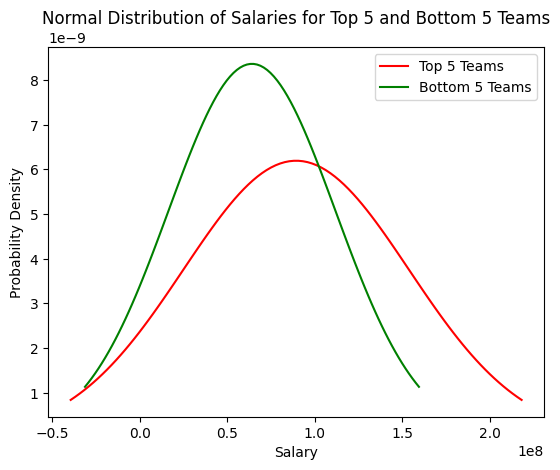

In [12]:
# Data for plotting the normal distribution for the top 5 teams

top_5_teams_x_values = [salary_stats_top5['mean'] + 2 * salary_stats_top5['std_dev'], salary_stats_top5['mean'] - 2 * salary_stats_top5['std_dev']]
top_5_teams_x_fit = np.linspace(top_5_teams_x_values[1], top_5_teams_x_values[0], 100)
top_5_teams_y_fit = dal.gaussian_prob(top_5_teams_x_fit, salary_stats_top5['mean'], salary_stats_top5['std_dev'])

# Data for plotting the normal distribution for the bottom 5 teams

bot_5_teams_x_values = [salary_stats_bot5['mean'] + 2 * salary_stats_bot5['std_dev'], salary_stats_bot5['mean'] - 2 * salary_stats_bot5['std_dev']]
bot_5_teams_x_fit = np.linspace(bot_5_teams_x_values[1], bot_5_teams_x_values[0], 100)
bot_5_teams_y_fit = dal.gaussian_prob(bot_5_teams_x_fit, salary_stats_bot5['mean'], salary_stats_bot5['std_dev'])

# Plotting the normal distributions for the top 5 and bottom 5 teams

# plt.figure(figsize=(20, 6))
plt.plot(top_5_teams_x_fit, top_5_teams_y_fit, label='Top 5 Teams', color='red')
plt.plot(bot_5_teams_x_fit, bot_5_teams_y_fit, label='Bottom 5 Teams', color='green')
plt.title('Normal Distribution of Salaries for Top 5 and Bottom 5 Teams')
plt.xlabel('Salary')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# Exercise 5

## Write a python function that computes the correlation coefficient between winning percentage and salary for each team for the years 1986 – 2025. The function should return the team name and its correlation coefficient sorted from highest to lowest in the correlation coefficient.

In [13]:
def teams_corelation_coef(team_data_structure):
    team_correlation = {}
    
    for team in team_data_structure:
        win_percentages = team_data_structure[team]['win_percentage']
        salaries = team_data_structure[team]['salary']
        
        correlation = dal.find_data_correlation(win_percentages, salaries)
        team_correlation[team] = correlation
        
    sorted_team_correlation = dict(sorted(team_correlation.items(), key=lambda x: x[1], reverse=True))
    
    # Cleaning the data, turning it back into python and rounding
    for team in sorted_team_correlation:
        sorted_team_correlation[team] = round(sorted_team_correlation[team], 3)

    return sorted_team_correlation

team_correlation_coefficients = teams_corelation_coef(team_data_structure)

for team in team_correlation_coefficients:
    print(f"{team}, Correlation Coefficient: {team_correlation_coefficients[team]}")


Los Angeles Dodgers, Correlation Coefficient: 0.619
Milwaukee Brewers, Correlation Coefficient: 0.566
Florida Marlins, Correlation Coefficient: 0.522
Washington Nationals, Correlation Coefficient: 0.475
Philadelphia Phillies, Correlation Coefficient: 0.421
Chicago Cubs, Correlation Coefficient: 0.283
St. Louis Cardinals, Correlation Coefficient: 0.24
San Diego Padres, Correlation Coefficient: 0.212
Atlanta Braves, Correlation Coefficient: 0.202
Arizona Diamondbacks, Correlation Coefficient: 0.195
Pittsburgh Pirates, Correlation Coefficient: 0.17
Miami Marlins, Correlation Coefficient: -0.049
New York Mets, Correlation Coefficient: -0.058
Houston Astros, Correlation Coefficient: -0.093
San Francisco Giants, Correlation Coefficient: -0.171
Montreal Expos, Correlation Coefficient: -0.191
Colorado Rockies, Correlation Coefficient: -0.301
Cincinnati Reds, Correlation Coefficient: -0.34


# Exercise 6

## Let’s collect some performance stats for the “best 5 teams” by winning percentage. For all years, 1986 – 2025, every time a team makes the “best 5 teams” list, let’s record the position the team achieved for that year. What would be a good data structure to implement this? What do we need to worry about when we assign a finish number to a team? Write a Python function do to this.

In [14]:
def team_top_5_finishes(yearly_data_structure):
    top_5_finishes = {}


    for year in yearly_data_structure:
        teams = yearly_data_structure[year]['teams']
        win_percentages = yearly_data_structure[year]['win_percentage']


        team_wp = [(teams[i], win_percentages[i]) for i in range(len(teams))]
        sorted_by_wp = sorted(team_wp, key=lambda x: x[1], reverse=True)

        # Threshold wp is the last place in the top 5, helps me know when to stop counting
        threshold_wp = sorted_by_wp[4][1]

        prev_wp = None
        final_position = 0

        # Looping through the tuple to check if anything past the 5th position is equal to the 5th position (accounting for duplicates), and creating the keys and lists for my dictionary
        for (team_name, wp_val) in sorted_by_wp:
            
            # If the current wp is less than the threshold, stop checking right there
            if wp_val < threshold_wp:
                break
                
            # Check to see if the current wp is the same as the last one to account for duplicates, if not make the position/counter go up one
            if wp_val != prev_wp:
                final_position += 1

            if team_name not in top_5_finishes:
                top_5_finishes[team_name] = []

            top_5_finishes[team_name].append(final_position)

            prev_wp = wp_val


    return top_5_finishes


team_top_5_finishes_data = team_top_5_finishes(yearly_data_structure)

print(team_top_5_finishes_data)


{'New York Mets': [1, 2, 1, 4, 2, 4, 4, 3, 5, 1, 5, 4, 5, 4, 2, 4], 'Houston Astros': [2, 5, 4, 5, 2, 3, 1, 5, 4, 3, 5], 'Philadelphia Phillies': [3, 3, 4, 3, 3, 2, 2, 1, 1, 4, 2, 2], 'Cincinnati Reds': [4, 5, 3, 2, 3, 3, 2, 5, 3, 2, 5, 5], 'San Francisco Giants': [5, 4, 2, 4, 2, 3, 5, 1, 3, 4, 2, 5, 5, 2, 3, 4, 4, 1], 'St. Louis Cardinals': [1, 5, 4, 5, 5, 4, 2, 1, 3, 1, 1, 4, 4, 4, 4, 1, 3, 1, 4, 5, 4, 3], 'Montreal Expos': [3, 4, 4, 4, 1, 4], 'Los Angeles Dodgers': [2, 3, 3, 5, 3, 3, 4, 4, 5, 3, 2, 1, 4, 2, 4, 3, 1, 3, 1, 1, 2, 1, 2, 1, 3], 'Pittsburgh Pirates': [4, 1, 1, 2, 3, 4, 2], 'San Diego Padres': [5, 3, 4, 2, 3, 2, 4, 4, 2, 4, 3, 5], 'Chicago Cubs': [1, 4, 4, 4, 1, 3, 1, 4, 2, 4, 4], 'Atlanta Braves': [2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 4, 1, 1, 2, 2, 3, 5, 3, 2, 5, 2, 3, 5, 2, 1, 4], 'Colorado Rockies': [4, 2, 3, 5, 4], 'Florida Marlins': [2, 3, 5], 'Arizona Diamondbacks': [2, 2, 2, 1, 3, 3, 5, 4], 'Milwaukee Brewers': [3, 2, 1, 5, 3, 3, 3, 1], 'Washington Nationals': [1, 1, 2, 

# Exercise 7

## Using the data structure from Exercise 6 let’s compute some statistic for team’s best 5 finishes. For each team’s best 5 finishes compute the number of best 5 finishes, the mean value for the finishes, the median value for the finishes, and the number of times the team had a first-place finish.

In [15]:
best_finishes_stats = {}

for team_name in team_top_5_finishes_data:
    finishes = team_top_5_finishes_data[team_name]
    
    num_finishes = len(finishes)
    mean_finishes = dal.main_stats(finishes)['mean']
    median_finishes = dal.main_stats(finishes)['median']
    first_place_finishes = finishes.count(1)
    
    best_finishes_stats[team_name] = {
        'num_finishes': num_finishes,
        'mean_finishes': mean_finishes,
        'median_finishes': median_finishes,
        'first_place_finishes': first_place_finishes
    }

best_finishes_stats = sorted(best_finishes_stats.items(), key=lambda x: x[1]['num_finishes'], reverse = True)

print(best_finishes_stats)

[('Atlanta Braves', {'num_finishes': 26, 'mean_finishes': 2.23, 'median_finishes': 2.0, 'first_place_finishes': 10}), ('Los Angeles Dodgers', {'num_finishes': 25, 'mean_finishes': 2.64, 'median_finishes': 3.0, 'first_place_finishes': 6}), ('St. Louis Cardinals', {'num_finishes': 22, 'mean_finishes': 3.14, 'median_finishes': 4.0, 'first_place_finishes': 6}), ('San Francisco Giants', {'num_finishes': 18, 'mean_finishes': 3.28, 'median_finishes': 3.5, 'first_place_finishes': 2}), ('New York Mets', {'num_finishes': 16, 'mean_finishes': 3.19, 'median_finishes': 4.0, 'first_place_finishes': 3}), ('Philadelphia Phillies', {'num_finishes': 12, 'mean_finishes': 2.5, 'median_finishes': 2.5, 'first_place_finishes': 2}), ('Cincinnati Reds', {'num_finishes': 12, 'mean_finishes': 3.5, 'median_finishes': 3.0, 'first_place_finishes': 0}), ('San Diego Padres', {'num_finishes': 12, 'mean_finishes': 3.42, 'median_finishes': 3.5, 'first_place_finishes': 0}), ('Houston Astros', {'num_finishes': 11, 'mean_f

# Exercise 8

## Now let’s collect some salary stats for some selected teams with high and low correlation coefficients by winning percentage. We’ll look at the Los Angles Dodgers, Milwaukee Brewers, New York Mets , San Francisco Giants , Atlanta Braves , and Philadelphia Phillies. Since the Milwaukee Brewers joined the National League in 1998 we’ll collect salary statistics (mean, median, standard deviation, min and max) for the above teams from 1998 – 2025. This will allow us to remove a lower salary basis for the teams that have been in the National League since 1986. Put your results into a table. Write a Python function do to this.

In [16]:
def salary_stats_1998_forward(yearly_data_structure, team_name):
    team_data = {}
    salaries = []
    
    for year in yearly_data_structure:
        if year >= 1998:
            teams = yearly_data_structure[year]['teams']
            salaries_year = yearly_data_structure[year]['salary']
            
            for i in range(len(teams)):
                if teams[i] == team_name:
                    salaries.append(salaries_year[i])
                    
    salary_stats = dal.main_stats(salaries)

    return salary_stats

dodgers_salary_stats_1998_2025 = salary_stats_1998_forward(yearly_data_structure, 'Los Angeles Dodgers')
brewers_salary_stats_1998_2025 = salary_stats_1998_forward(yearly_data_structure, 'Milwaukee Brewers')
mets_salary_stats_1998_2025 = salary_stats_1998_forward(yearly_data_structure, 'New York Mets')
giants_salary_stats_1998_2025 = salary_stats_1998_forward(yearly_data_structure, 'San Francisco Giants')
braves_salary_stats_1998_2025 = salary_stats_1998_forward(yearly_data_structure, 'Atlanta Braves')
phillies_salary_stats_1998_2025 = salary_stats_1998_forward(yearly_data_structure, 'Philadelphia Phillies')

salary_stats_years_1998_2025 = {
    'Los Angeles Dodgers': dodgers_salary_stats_1998_2025,
    'Milwaukee Brewers': brewers_salary_stats_1998_2025,
    'New York Mets': mets_salary_stats_1998_2025,
    'San Francisco Giants': giants_salary_stats_1998_2025,
    'Atlanta Braves': braves_salary_stats_1998_2025,
    'Philadelphia Phillies': phillies_salary_stats_1998_2025
}

pd.DataFrame(salary_stats_years_1998_2025)

,Los Angeles Dodgers,Milwaukee Brewers,New York Mets,San Francisco Giants,Atlanta Braves,Philadelphia Phillies
mean,1.528209e+08,7.454390e+07,1.370106e+08,1.180380e+08,1.100414e+08,1.244152e+08
median,1.087177e+08,8.105622e+07,1.083205e+08,1.077248e+08,9.266098e+07,1.121910e+08
variance,4.711873e+15,7.876297e+14,5.197807e+15,2.326137e+15,1.822288e+15,3.764749e+15
std_dev,6.864308e+07,2.806474e+07,7.209582e+07,4.823004e+07,4.268827e+07,6.135755e+07
max,2.771083e+08,1.247554e+08,3.342333e+08,2.085100e+08,2.253150e+08,2.361826e+08
min,6.073167e+07,2.751850e+07,5.866066e+07,4.599193e+07,6.184025e+07,2.992250e+07
